<a href="https://colab.research.google.com/github/latika0128/Human-Activity-Recognition/blob/main/DL_Human_Activity_Recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HUMAN ACTIVITY RECOGNITION

In [ ]:
# Install packages
!pip install -q tensorflow seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile, os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


# 1. DOWNLOAD & EXTRACT DATASET
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
!wget -q $url -O har.zip
!unzip -q har.zip

In [ ]:
# 2. LOAD DATA
X_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt", delim_whitespace=True, header=None
)
y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt", header=None
)[0]

X_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt", delim_whitespace=True, header=None
)
y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt", header=None
)[0]

# Convert labels from 1–6 to 0–5
y_train -= 1
y_test -= 1

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

/tmp/ipykernel_6475/2997661023.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(
/tmp/ipykernel_6475/2997661023.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(


Train shape: (7352, 561)
Test shape: (2947, 561)


In [ ]:
# 3. FEATURE SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 4. MACHINE LEARNING MODELS
lr = LogisticRegression(max_iter=1000)
svm = SVC(kernel="rbf")
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# 5. ARTIFICIAL NEURAL NETWORK
ann = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(6, activation="softmax")
])

ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 6. EVALUATION
models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

print("\n--- MACHINE LEARNING RESULTS ---")
for name, model in models.items():
    preds = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))

ann_preds = ann.predict(X_test).argmax(axis=1)

print("\n--- ANN RESULTS ---")
print("ANN Accuracy:", accuracy_score(y_test, ann_preds))
print(classification_report(y_test, ann_preds))


--- MACHINE LEARNING RESULTS ---

Logistic Regression
Accuracy: 0.9548693586698337
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       496
           1       0.96      0.95      0.95       471
           2       0.99      0.94      0.96       420
           3       0.97      0.88      0.92       491
           4       0.89      0.97      0.93       532
           5       1.00      0.99      0.99       537

    accuracy                           0.95      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.96      0.95      0.95      2947


SVM
Accuracy: 0.9521547336274178
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       496
           1       0.93      0.97      0.95       471
           2       0.98      0.92      0.95       420
           3       0.94      0.90      0.92       491
           4       0.92      0.95      0.93       532
           5  

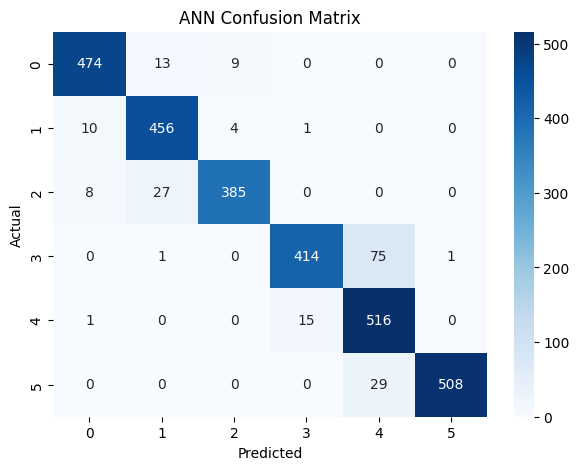

In [ ]:
# 7. CONFUSION MATRIX (ANN)
cm = confusion_matrix(y_test, ann_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

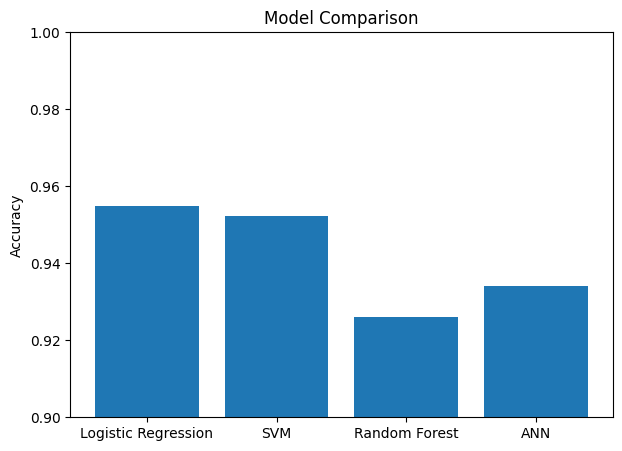


Final Accuracies: {'Logistic Regression': 0.9548693586698337, 'SVM': 0.9521547336274178, 'Random Forest': 0.9260264675941635, 'ANN': 0.9341703427214116}


In [ ]:
# 8. ACCURACY COMPARISON
accuracies = {
    "Logistic Regression": accuracy_score(y_test, lr.predict(X_test)),
    "SVM": accuracy_score(y_test, svm.predict(X_test)),
    "Random Forest": accuracy_score(y_test, rf.predict(X_test)),
    "ANN": accuracy_score(y_test, ann_preds)
}

plt.figure(figsize=(7,5))
plt.bar(accuracies.keys(), accuracies.values())
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

print("\nFinal Accuracies:", accuracies)